# SVM for classification

Load IRIS dataset, check its contents:


In [ ]:
from sklearn.datasets import load_iris
iris=load_iris()
iris.feature_names
print(iris.feature_names)
print(iris.data[0:5,:])
print(iris.target[0:5])
#print(iris.data)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
[0 0 0 0 0]


Split data into training and testing parts:

In [ ]:
from sklearn.model_selection import train_test_split
X=iris.data
y=iris.target
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
print(X_train.shape)
print(X_test.shape)

(120, 4)
(30, 4)


Use a Support Vector Machine for classification:


In [ ]:
from sklearn.svm import SVC
SVMmodel=SVC(kernel='linear')
SVMmodel.fit(X_train,y_train)
SVMmodel.get_params()
SVMmodel.score(X_test,y_test)

0.9333333333333333

Let's explore more now.

*   Choose only first two features (columns) of iris.data
*   SVM is in its basic form a 2-class classifier, so eliminate iris.target =2 from the data



In [ ]:
import numpy as np

# Select the first two columns of the iris.data array
X_two_features = iris.data[:, :2]

# Create a boolean mask to identify the rows where iris.target is not equal to 2
mask = (iris.target != 2)

# Apply this mask to X_two_features to create X_filtered
X_filtered = X_two_features[mask]

# Apply the same mask to iris.target to create y_filtered
y_filtered = iris.target[mask]

# Print the shape of X_filtered and y_filtered to confirm
print(f"Shape of X_filtered: {X_filtered.shape}")
print(f"Shape of y_filtered: {y_filtered.shape}")

Shape of X_filtered: (100, 2)
Shape of y_filtered: (100,)


Plot scatterplots of targets 0 and 1 and check the separability of the classes

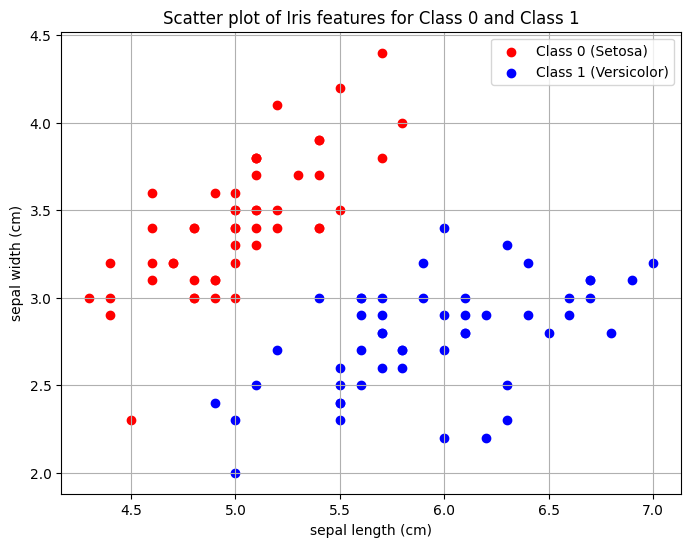

In [ ]:
import matplotlib.pyplot as plt

# Separate the filtered data into class 0 and class 1
X_class0 = X_filtered[y_filtered == 0]
X_class1 = X_filtered[y_filtered == 1]

# Create the scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(X_class0[:, 0], X_class0[:, 1], color='red', label='Class 0 (Setosa)')
plt.scatter(X_class1[:, 0], X_class1[:, 1], color='blue', label='Class 1 (Versicolor)')

# Add labels and title
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title('Scatter plot of Iris features for Class 0 and Class 1')
plt.legend()
plt.grid(True)
plt.show()

Train and test the SVM classifier, play with

*   Élément de liste
*   Élément de liste

regularization parameter C (either use the default value or try e.g. 200)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

# Split the filtered data into training and testing parts
X_train_filtered, X_test_filtered, y_train_filtered, y_test_filtered = train_test_split(X_filtered, y_filtered, test_size=0.2, random_state=42)

# Initialize and train the SVM model with a linear kernel and C=200
SVMmodel_filtered = SVC(kernel='linear', C=200)
SVMmodel_filtered.fit(X_train_filtered, y_train_filtered)

# Get the parameters of the trained model
print("Model parameters:")
print(SVMmodel_filtered.get_params())

# Evaluate the model's score on the test set
score_filtered = SVMmodel_filtered.score(X_test_filtered, y_test_filtered)
print(f"\nAccuracy of SVM with C=200 on filtered data: {score_filtered:.4f}")

Model parameters:
{'C': 200, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'linear', 'max_iter': -1, 'probability': False, 'random_state': None, 'shrinking': True, 'tol': 0.001, 'verbose': False}

Accuracy of SVM with C=200 on filtered data: 1.0000


Show support vectors in the 2D plot, plot the decision line from equation [w0 w1]*[x0 x1] + b = 0:

In [ ]:
supvectors=SVMmodel.support_vectors_
# Plot the support vectors here


#Separating line coefficients:
W=SVMmodel.coef_
b=SVMmodel.intercept_


# Anomaly detection via SVM

Import one-class SVM and generate data (Gaussian blobs in 2D-plane):

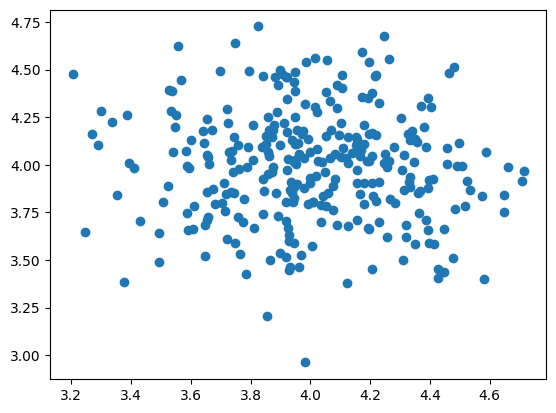

In [ ]:
from sklearn.svm import OneClassSVM
from sklearn.datasets import make_blobs
from numpy import quantile, where, random

random.seed(11)
x, _ = make_blobs(n_samples=300, centers=1, cluster_std=.3, center_box=(4, 4))

plt.scatter(x[:,0], x[:,1])
plt.show()



Train one-class SVM and plot the outliers (outputs of prediction being equal to -1)

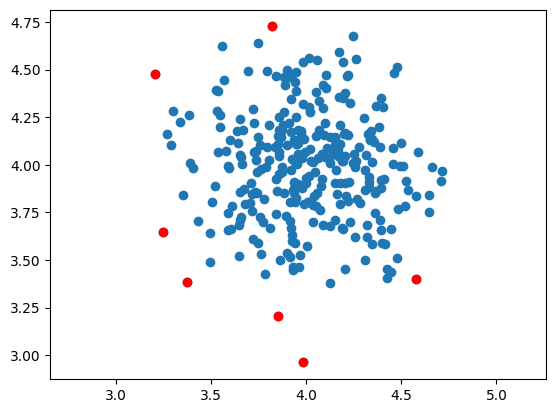

In [ ]:
from sklearn.svm import OneClassSVM
from numpy import where

SVMmodelOne = OneClassSVM(kernel='rbf', gamma=0.001, nu=0.03)
SVMmodelOne.fit(x)
pred = SVMmodelOne.predict(x)
anom_index = where(pred==-1)
values = x[anom_index]

plt.scatter(x[:,0], x[:,1])
plt.scatter(values[:,0], values[:,1], color='red')
plt.axis('equal')
plt.show()



Plot the support vectors:

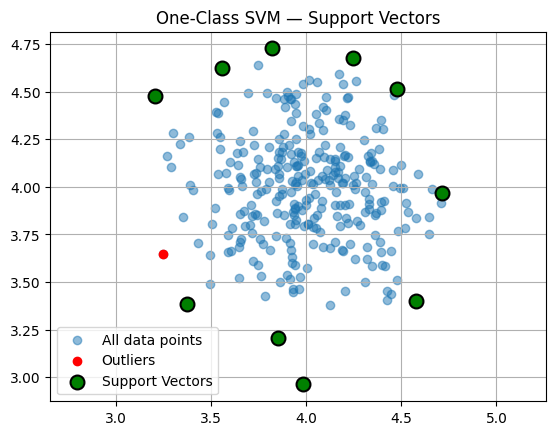

Nombre de support vectors : 10


In [ ]:
sv = SVMmodelOne.support_vectors_

plt.scatter(x[:, 0], x[:, 1], label='All data points', alpha=0.5)
plt.scatter(values[:, 0], values[:, 1], color='red', label='Outliers', zorder=3)
plt.scatter(sv[:, 0], sv[:, 1], color='green', s=100,
            edgecolors='black', linewidths=1.5, label='Support Vectors', zorder=4)
plt.axis('equal')
plt.title('One-Class SVM — Support Vectors')
plt.legend()
plt.grid(True)
plt.show()

print(f"Nombre de support vectors : {len(sv)}")

What if we want to have a control what is outlier? Use e.g. 5% "quantile" to mark the outliers. Every point with lower score than threshold will be an outlier.

8.987833799021839


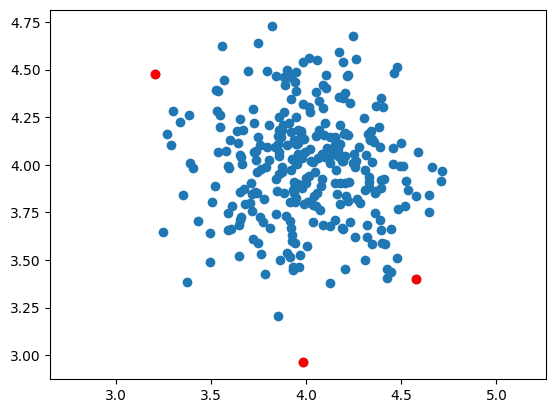

In [ ]:
scores = SVMmodelOne.score_samples(x)

thresh = quantile(scores, 0.01)
print(thresh)
index = where(scores<=thresh)
values = x[index]

plt.scatter(x[:,0], x[:,1])
plt.scatter(values[:,0], values[:,1], color='red')
plt.axis('equal')
plt.show()

# Task
Select the first two features from the `iris.data` dataset and filter out data points where `iris.target` is equal to 2. Store the filtered features in `X_filtered` and the filtered targets in `y_filtered`. Finally, print the shapes of `X_filtered` and `y_filtered` to confirm the updated dataset dimensions.

## Select Features and Filter Data

### Subtask:
Select the first two features (columns) from `iris.data` and filter out data points where `iris.target` is equal to 2. Store the filtered features and targets in new variables.


**Reasoning**:
The subtask requires selecting the first two features of the Iris dataset, filtering out the third class, and storing the results in new variables. This will be done by creating a boolean mask and applying it to both features and targets.



In [ ]:
import numpy as np

# 1. Select the first two columns of the iris.data array
X_two_features = iris.data[:, :2]

# 2. Create a boolean mask to identify the rows where iris.target is not equal to 2
mask = (iris.target != 2)

# 3. Apply this mask to X_two_features to create X_filtered
X_filtered = X_two_features[mask]

# 4. Apply the same mask to iris.target to create y_filtered
y_filtered = iris.target[mask]

# 5. Print the shape of X_filtered
print(f"Shape of X_filtered: {X_filtered.shape}")

# 6. Print the shape of y_filtered
print(f"Shape of y_filtered: {y_filtered.shape}")

Shape of X_filtered: (100, 2)
Shape of y_filtered: (100,)


## Final Task

### Subtask:
Confirm the updated dataset dimensions and characteristics.


## Summary:

### Q&A
The updated dataset dimensions have been confirmed. `X_filtered` has a shape of (100, 2), and `y_filtered` has a shape of (100,).

### Data Analysis Key Findings
*   The first two features from the `iris.data` dataset were successfully selected.
*   Data points where `iris.target` was equal to 2 were filtered out.
*   `X_filtered`, containing the first two features for the remaining data points, has a shape of (100, 2), indicating 100 samples with 2 features each.
*   `y_filtered`, containing the corresponding target values, has a shape of (100,), indicating 100 target values.
*   The filtering process successfully reduced the dataset from 150 to 100 samples by removing the 50 data points associated with `iris.target` equal to 2.

### Insights or Next Steps
*   The filtered dataset now contains only data points from classes other than class 2, which is ready for specific classification or clustering tasks focusing on these remaining classes.
*   The reduced dimensionality (2 features) and filtered samples could be beneficial for visualizing the data distribution or training models on a subset of the original data.
